# Polynomial chaos expansions


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc

In [2]:
mu = 3.986e14  # Gravitational constant [m^3/s^2]
r_p0 = 6.678e6  # Parking-orbit radius [m]
r_a0 = 4.2164e7  # Initial apogee radius [m]


def propagate_burn(dr_a, dnu, dv_mag, dv_dir):
    # Transfer orbit
    r_a = r_a0 + dr_a  # Actual apogee radius w/ dispersion [m]
    a_t = (r_p0 + r_a) / 2  # Semi-major axis [m]
    e_t = (r_a - r_p0) / (r_a + r_p0)  # Eccentricity
    h = np.sqrt(mu * a_t * (1 - e_t**2))  # Angular momentum [m^2/s]

    nu = np.radians(180) + dnu  # True anomaly at burn [rad]

    # Local radius and radial/tangential velocity at burn
    r = a_t * (1 - e_t**2) / (1 + e_t * np.cos(nu))  # Radius [m]
    v_t = (mu / h) * (1 + e_t * np.cos(nu))  # Tangential velocity [m/s]
    v_r = (mu / h) * e_t * np.sin(nu)  # Radial velocity [m/s]

    # Delta-v for circularization burn
    v_circ = np.sqrt(mu / r_a0)  # Circular velocity at apogee [m/s]
    v_t_nom = (mu / h) * (1 - e_t)  # Nominal tangential velocity at burn [m/s]
    dv_nom = v_circ - v_t_nom  # Nominal delta-v [m/s]

    # Add dispersion to delta-v magnitude and direction
    dv_mag = dv_nom + dv_mag  # Actual delta-v magnitude [m/s]
    dv_r = dv_mag * np.sin(dv_dir)  # Radial component of delta-v [m/s]
    dv_t = dv_mag * np.cos(dv_dir)  # Tangential component of delta-v [m/s]

    # Final orbit after burn
    v_r_f = v_r + dv_r  # Final radial velocity [m/s]
    v_t_f = v_t + dv_t  # Final tangential velocity [m/s]
    E_f = 0.5 * v_r_f**2 + 0.5 * v_t_f**2 - mu / r  # Specific energy [m^2/s^2]
    a_f = -mu / (2 * E_f)  # Semi-major axis [m]
    h_f = r * v_t_f  # Angular momentum [m^2/s]
    e_f = np.sqrt(1 - np.fmin(1, h_f**2 / (mu * a_f)))  # Eccentricity
    r_a_f = a_f * (1 + e_f)  # Final apogee radius [m]
    r_p_f = a_f * (1 - e_f)  # Final perigee radius [m]

    return e_f, r_a_f, r_p_f


@arc.compile(buffered=True)
def f_buffered(dr_a, dnu, dv_mag, dv_dir):
    return propagate_burn(dr_a, dnu, dv_mag, dv_dir)


# Monte Carlo
sigma_dr_a = 100e3  # Apogee radius dispersion [m]
sigma_dnu = np.radians(0.1)  # True anomaly dispersion [rad]
sigma_dv_mag = 5.0  # Delta-v magnitude dispersion [m/s]
sigma_dv_dir = np.radians(0.3)  # Delta-v direction dispersion [rad]

n_samples = 1_000_000
e_samples = np.zeros(n_samples)
r_a_samples = np.zeros(n_samples)
r_p_samples = np.zeros(n_samples)
dr_a_samples = np.random.normal(0, sigma_dr_a, n_samples)
dnu_samples = np.random.normal(0, sigma_dnu, n_samples)
dv_mag_samples = np.random.normal(0, sigma_dv_mag, n_samples)
dv_dir_samples = np.random.normal(0, sigma_dv_dir, n_samples)
for i in range(n_samples):
    dr_a = dr_a_samples[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e_samples[i], r_a_samples[i], r_p_samples[i] = f_buffered(dr_a, dnu, dv_mag, dv_dir)

In [3]:
r_a_err = r_a_samples - r_a0
r_p_err = r_p_samples - r_a0
max_is_apogee = abs(r_a_err) > abs(r_p_err)
r_err = np.where(max_is_apogee, r_a_err, r_p_err)

In [4]:
print(np.mean(r_err) / 1e3)

1.1026891932948517


In [5]:
print(np.std(r_err) / 1e3)

300.0890505205301


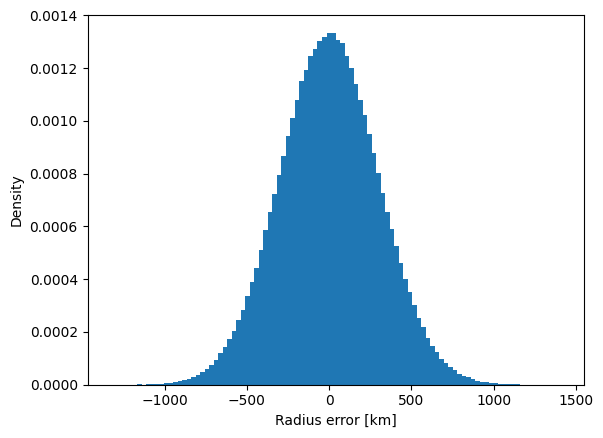

In [6]:

plt.hist(r_err / 1e3, bins=100, density=True)
plt.xlabel("Radius error [km]")
plt.ylabel("Density")
plt.show()

In [7]:
from scipy.stats import kurtosis, skew

print(f"Skewness: {skew(r_err):.4f}")
print(f"Kurtosis: {kurtosis(r_err, fisher=False):.4f}")

Skewness: 0.0183
Kurtosis: 3.0090


Text(0, 0.5, 'Mean radius error [km]')

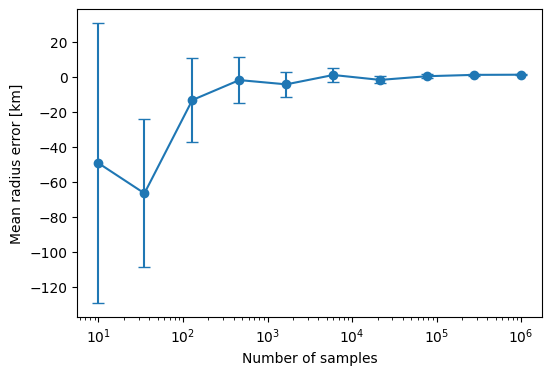

In [8]:
n_conv = np.logspace(1, np.log10(n_samples), num=10, dtype=int)
r_err_mean = np.zeros_like(n_conv, dtype=float)
r_err_std = np.zeros_like(n_conv, dtype=float)
for i, n in enumerate(n_conv):
    r_err_mean[i] = np.mean(r_err[:n])
    r_err_std[i] = np.std(r_err[:n]) / np.sqrt(n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(n_conv, r_err_mean / 1e3, yerr=r_err_std / 1e3, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Mean radius error [km]")

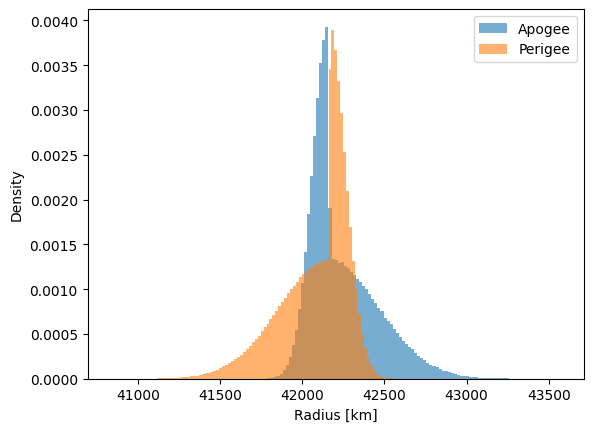

In [9]:
import matplotlib.pyplot as plt

plt.hist(r_a_samples / 1e3, bins=100, density=True, alpha=0.6, label="Apogee")
plt.hist(r_p_samples / 1e3, bins=100, density=True, alpha=0.6, label="Perigee")
plt.legend()
plt.xlabel("Radius [km]")
plt.ylabel("Density")
plt.show()

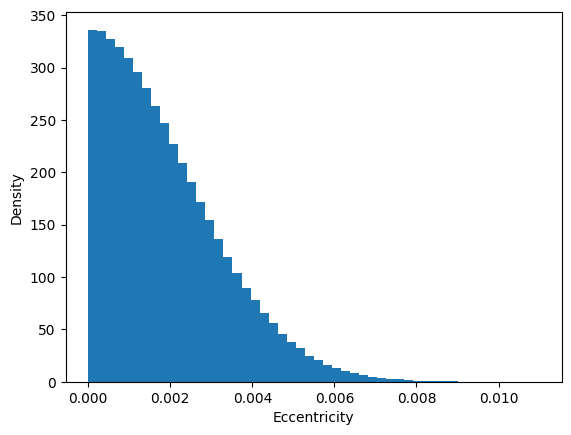

In [10]:
import matplotlib.pyplot as plt

plt.hist(e_samples, bins=50, density=True)
plt.xlabel("Eccentricity")
plt.ylabel("Density")
plt.show()

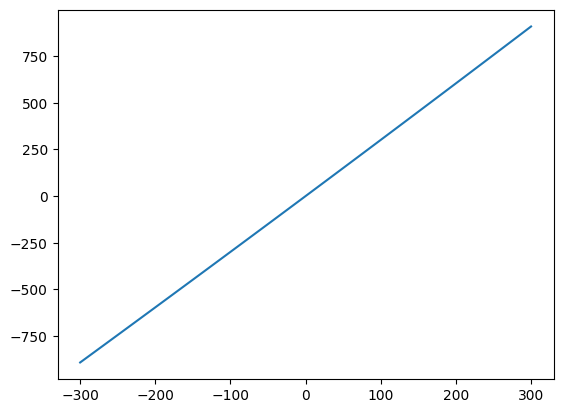

In [11]:
dr_a_sweep = np.linspace(-3 * sigma_dr_a, 3 * sigma_dr_a, 100)
r_err_sweep = np.zeros_like(dr_a_sweep, dtype=float)

for i in range(len(dr_a_sweep)):
    dr_a = dr_a_sweep[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    r_a_err = r_a - r_a0
    r_p_err = r_p - r_a0
    max_is_apogee = abs(r_a_err) > abs(r_p_err)
    r_err_sweep[i] = r_a_err if max_is_apogee else r_p_err


plt.plot(dr_a_sweep / 1e3, r_err_sweep / 1e3)

## 1. Setting up the representation

Say your uncertain inputs are collected into a vector of $d$ independent standard Gaussian random variables $\boldsymbol{\xi} = (\xi_1, \dots, \xi_d)$, and your output is $Y = f(\boldsymbol{\xi})$ for some (possibly expensive, black-box) model $f$. If $Y$ has finite variance, the Cameron–Martin theorem guarantees it has a convergent expansion in multivariate **Hermite polynomials**, which form a complete orthogonal basis for $L^2$ under Gaussian measure:

$$Y = f(\boldsymbol{\xi}) = \sum_{\alpha} c_\alpha \Psi_\alpha(\boldsymbol{\xi})$$

Here $\alpha = (\alpha_1, \dots, \alpha_d)$ is a multi-index and

$$\Psi_\alpha(\boldsymbol{\xi}) = \prod_{i=1}^{d} He_{\alpha_i}(\xi_i)$$

using the **probabilists' Hermite polynomials**: $He_0 = 1$, $He_1(x) = x$, $He_2(x) = x^2 - 1$, $He_3(x) = x^3 - 3x$, with recurrence $He_{n+1}(x) = x\,He_n(x) - n\,He_{n-1}(x)$.

The key structural fact is orthogonality with respect to the standard normal density $\varphi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$:

$$\mathbb{E}[He_m(\xi)\,He_n(\xi)] = \int He_m(x)He_n(x)\,\varphi(x)\,dx = n!\,\delta_{mn}$$

so in the multivariate case $\mathbb{E}[\Psi_\alpha \Psi_\beta] = \gamma_\alpha \,\delta_{\alpha\beta}$, with $\gamma_\alpha = \alpha! = \prod_i \alpha_i!$.

In practice you truncate to total degree $\le p$, leaving $P+1 = \binom{d+p}{p}$ terms — this truncation is really the only approximation being made at the representation level; everything else is about computing the coefficients accurately.

## 2. Determining the coefficients

Because $\{\Psi_\alpha\}$ is an orthogonal basis, each coefficient is just a projection — the same idea as a Fourier coefficient:

$$c_\alpha = \frac{\mathbb{E}[Y\,\Psi_\alpha(\boldsymbol{\xi})]}{\mathbb{E}[\Psi_\alpha^2(\boldsymbol{\xi})]} = \frac{1}{\alpha!}\int_{\mathbb{R}^d} f(\boldsymbol{\xi})\,\Psi_\alpha(\boldsymbol{\xi})\,\varphi(\boldsymbol{\xi})\,d\boldsymbol{\xi}$$

where $\varphi(\boldsymbol{\xi}) = \prod_i \varphi(\xi_i)$ is the joint standard Gaussian density. This is an exact formula, but the integral is generally not tractable analytically once $f$ is a real simulation — so for a non-intrusive approach you treat $f$ as a black box, evaluate it at a set of chosen points, and approximate the projection integral numerically. This is where quadrature comes in, and it's almost always the practical route.

## 3. Turning the projection into quadrature

Since the weight function $\varphi(\xi)$ is exactly the Gaussian weight, the natural quadrature rule is **Gauss–Hermite quadrature**.

**One dimension.** The "physicists'" Gauss–Hermite rule gives nodes/weights $(x_i, w_i)_{i=1}^n$ satisfying

$$\int_{-\infty}^{\infty} e^{-x^2} g(x)\,dx \approx \sum_{i=1}^n w_i\, g(x_i)$$

exact whenever $g$ is a polynomial of degree $\le 2n-1$. To match the standard-normal weight, substitute $\xi = \sqrt{2}\,x$:

$$\int f(\xi)\,\varphi(\xi)\,d\xi \approx \sum_{i=1}^n \frac{w_i}{\sqrt{\pi}}\, f(\sqrt{2}\,x_i)$$

So your quadrature nodes in $\xi$-space are $\xi_i = \sqrt{2}\,x_i$ with rescaled weights $w_i' = w_i/\sqrt{\pi}$ (these sum to 1, as a probability weight should).

**Multiple dimensions.** For independent Gaussian inputs, build a **tensor-product** rule: pick $n$ points per dimension, and the full multivariate grid is

$$\{\boldsymbol{\xi}^{(k)}\} = \{(\xi_{i_1}, \dots, \xi_{i_d})\}, \qquad W^{(k)} = \prod_{j=1}^d w'_{i_j}$$

so the coefficients become finite sums:

$$c_\alpha \approx \frac{1}{\alpha!}\sum_{k=1}^{n^d} W^{(k)}\, f(\boldsymbol{\xi}^{(k)})\,\Psi_\alpha(\boldsymbol{\xi}^{(k)})$$

**Choosing $n$.** A common rule of thumb: if you truncate the PCE at total degree $p$, use $n = p+1$ points per dimension. That's exact for integrating a degree-$2p+1$ polynomial, which covers $\Psi_\alpha$ (degree $\le p$) times another degree-$p$ polynomial approximation of $f$. If $f$ is not well-approximated by a low-degree polynomial (strong nonlinearity), you'll want more quadrature points than the PCE order strictly requires, and you should check convergence by increasing $n$ and watching the coefficients stabilize.

## Quick summary of the workflow

1. Pick Hermite polynomials as basis (because inputs are Gaussian — for other input distributions you'd pick the matching orthogonal family per the **Askey scheme**, e.g. Legendre for uniform, Laguerre for gamma).
2. Truncate to a finite index set $|\alpha| \le p$.
3. Build a Gauss–Hermite quadrature grid (tensor product or sparse) in $\boldsymbol{\xi}$-space.
4. Evaluate $f$ at each quadrature node.
5. Compute each $c_\alpha$ as a weighted sum of $f(\boldsymbol{\xi}^{(k)})\Psi_\alpha(\boldsymbol{\xi}^{(k)})$, normalized by $\alpha!$.
6. Use the resulting expansion for cheap downstream statistics: mean is just $c_0$, variance is $\sum_{\alpha\neq 0} \alpha!\, c_\alpha^2$, and full moments/PDF can be estimated by sampling the cheap polynomial surrogate instead of the expensive $f$.

In [12]:
from archimedes.experimental.approximation import FunctionSpace


@arc.compile
def f(dr_a):
    dnu = 0
    dv_mag = 0
    dv_dir = 0
    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    r_a_err = r_a - r_a0
    r_p_err = r_p - r_a0
    max_is_apogee = abs(r_a_err) > abs(r_p_err)
    return np.where(max_is_apogee, r_a_err, r_p_err)


p = 3  # Polynomial order
fn_space = FunctionSpace.hermite(
    n_basis=p + 1,
    mean=0.0,
    std=sigma_dr_a,
    kind="prob",
    density=True,
)

# Express the random variable as a basis expansion in the function space
# by projecting the function `f` onto the basis functions using
# the quadrature rule for the normalized probabilists' Hermite polynomials.
# Note this is an approximation of `f` itself, not its output distribution.
f_pce = fn_space.project(f)

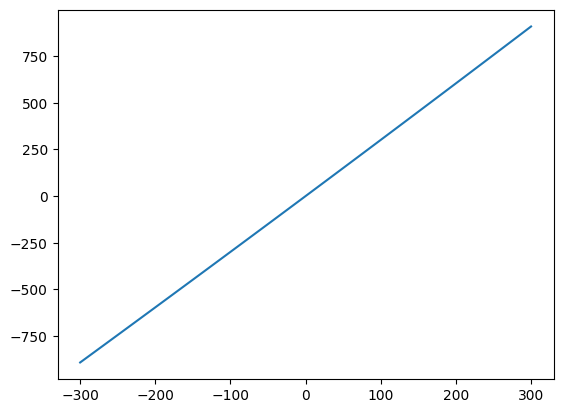

In [13]:
dr_a_sweep = np.linspace(-3 * sigma_dr_a, 3 * sigma_dr_a, 100)
r_err_sweep = f_pce(dr_a_sweep)

plt.plot(dr_a_sweep / 1e3, r_err_sweep / 1e3)

In [14]:
f_pce.coefficients

array([9.48692606e+02, 3.00006750e+05, 1.34167659e+03, 5.51145935e+00])

In [15]:
print(f"Mean: {f_pce.coefficients[0] / 1e3:.4f} m")
print(f"Std: {np.sqrt(np.sum(f_pce.coefficients[1:] ** 2)) / 1e3:.4f} m")

Mean: 0.9487 m
Std: 300.0098 m


## Multivariate distribution

In [16]:
# Monte Carlo
sigma_dr_a = 100e3  # Apogee radius dispersion [m]
sigma_dnu = np.radians(0.1)  # True anomaly dispersion [rad]
sigma_dv_mag = 5.0  # Delta-v magnitude dispersion [m/s]
sigma_dv_dir = np.radians(0.3)  # Delta-v direction dispersion [rad]

n_samples = 1_000_000
e_samples = np.zeros(n_samples)
r_a_samples = np.zeros(n_samples)
r_p_samples = np.zeros(n_samples)
dr_a_samples = np.random.normal(0, sigma_dr_a, n_samples)
dnu_samples = np.random.normal(0, sigma_dnu, n_samples)
dv_mag_samples = np.random.normal(0, sigma_dv_mag, n_samples)
dv_dir_samples = np.random.normal(0, sigma_dv_dir, n_samples)
for i in range(n_samples):
    dr_a = dr_a_samples[i]
    dnu = dnu_samples[i]
    dv_mag = dv_mag_samples[i]
    dv_dir = dv_dir_samples[i]

    e_samples[i], r_a_samples[i], r_p_samples[i] = f_buffered(dr_a, dnu, dv_mag, dv_dir)

In [17]:
r_a_err = r_a_samples - r_a0
r_p_err = r_p_samples - r_a0
max_is_apogee = abs(r_a_err) > abs(r_p_err)
r_err = np.where(max_is_apogee, r_a_err, r_p_err)

print(f"Mean radius error: {np.mean(r_err) / 1e3}")
print(f"Std radius error: {np.std(r_err) / 1e3}")

Mean radius error: 1.492995297678555
Std radius error: 454.7604734996853


In [18]:
std_err = np.std(r_a_err[:n]) / np.sqrt(n)
print(f"Mean apogee error: {np.mean(r_a_err) / 1e3:.4f} +/- {std_err / 1e3:.4f} km")
print(f"Std apogee error: {np.std(r_a_err) / 1e3:.4f} km")

Mean apogee error: 199.1535 +/- 0.2664 km
Std apogee error: 266.4430 km


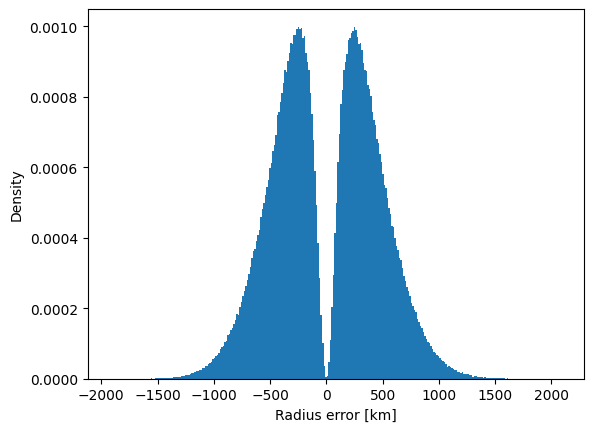

In [19]:
import matplotlib.pyplot as plt

plt.hist(r_err / 1e3, bins=300, density=True)
plt.xlabel("Radius error [km]")
plt.ylabel("Density")
plt.show()

In [20]:
from scipy.stats import kurtosis, skew

print(f"Skewness: {skew(r_err):.4f}")
print(f"Kurtosis: {kurtosis(r_err, fisher=False):.4f}")

Skewness: 0.0259
Kurtosis: 2.3965


Text(0, 0.5, 'Mean radius error [km]')

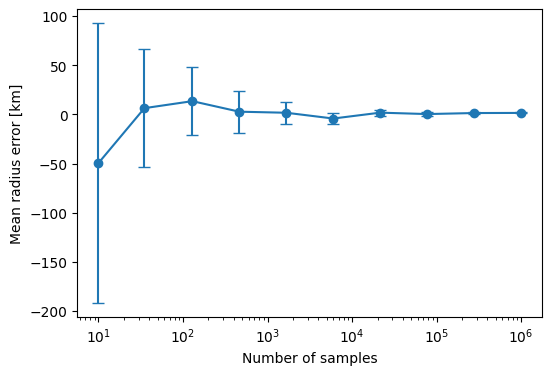

In [21]:
n_conv = np.logspace(1, np.log10(n_samples), num=10, dtype=int)
r_err_mean = np.zeros_like(n_conv, dtype=float)
r_err_std = np.zeros_like(n_conv, dtype=float)
for i, n in enumerate(n_conv):
    r_err_mean[i] = np.mean(r_err[:n])
    r_err_std[i] = np.std(r_err[:n]) / np.sqrt(n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(n_conv, r_err_mean / 1e3, yerr=r_err_std / 1e3, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Mean radius error [km]")

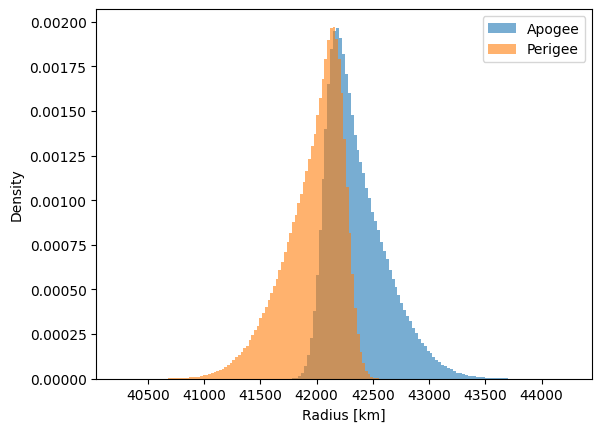

In [22]:
import matplotlib.pyplot as plt

plt.hist(r_a_samples / 1e3, bins=100, density=True, alpha=0.6, label="Apogee")
plt.hist(r_p_samples / 1e3, bins=100, density=True, alpha=0.6, label="Perigee")
plt.legend()
plt.xlabel("Radius [km]")
plt.ylabel("Density")
plt.show()

In [23]:
from archimedes.experimental.approximation import FunctionSpace


@arc.compile
def f_apogee(dp):
    dr_a, dnu, dv_mag, dv_dir = dp.T
    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    return r_a


p = 5  # Polynomial order (could be different per variable)


def hermite_basis(std):
    return FunctionSpace.hermite(n_basis=p + 1, mean=0.0, std=std, kind="prob", density=True)


# The full space is the tensor product of a 1D Hermite space per random variable
fn_space = FunctionSpace.tensor(
    hermite_basis(sigma_dr_a),
    hermite_basis(sigma_dnu),
    hermite_basis(sigma_dv_mag),
    hermite_basis(sigma_dv_dir),
)

# Express the random variable as a basis expansion in the function space
# by projecting the function `f_apogee` onto the basis functions using
# the quadrature rule for the normalized probabilists' Hermite polynomials.
# Note this is an approximation of `f_apogee` itself, not its output distribution.
f_pce = fn_space.project(f_apogee)

In [24]:
len(f_pce.coefficients)

1296

In [25]:
print(f"Mean apogee error: {(f_pce.coefficients[0] - r_a0) / 1e3:.4f} km")
print(f"Std apogee error: {np.sqrt(np.sum(f_pce.coefficients[1:] ** 2)) / 1e3:.4f} km")

Mean apogee error: 197.8966 km
Std apogee error: 267.5722 km


In [26]:
fn_space.basis

TensorBasis(bases=(OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x117996a20>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x1175af7a0>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x117c367b0>, n_basis=6, density=True), OrthogonalPolynomialBasis(measure=<archimedes.measure._hermite.ProbabilistsHermiteMeasure object at 0x117c6c920>, n_basis=6, density=True)))

In this case you could just as well do the polynomial chaos expansion in plain NumPy/SciPy or a specialized toolkit like [chaospy](https://chaospy.readthedocs.io/en/master/), since it's a non-intrusive algorithm that just requires sampling the black-box `arc.compile`d propagator function, and the PCE coefficients themselves give you the Sobol indices directly.
However, combining this with Archimedes' autodiff capabilities opens the door to interesting uncertainty-aware algorithms.
For instance, you could use PCE to estimate the mean and variance of some quantity of interest and then use this to optimize over deterministic design variables.